# Chapter 264 — Stochastic Processes and Queuing Theory
### Part VIII: Probability — Advanced Experiments

A **stochastic process** is a collection of random variables $\{X_t : t \in T\}$ indexed by time. Beyond Markov chains *(ch257)* and random walks *(ch258)*, this chapter covers the **Poisson process** (the canonical model for event arrivals) and **queuing theory** (the M/M/1 queue), which governs server design, network traffic, and customer service systems.

**Prerequisites:** Poisson Distribution (ch252), Exponential distribution *(via ch259)*, Markov Chains (ch257), Expected Value (ch249).

λ=3.0, T=20.0: observed 64 arrivals
Expected: 60.0, Std: 7.75


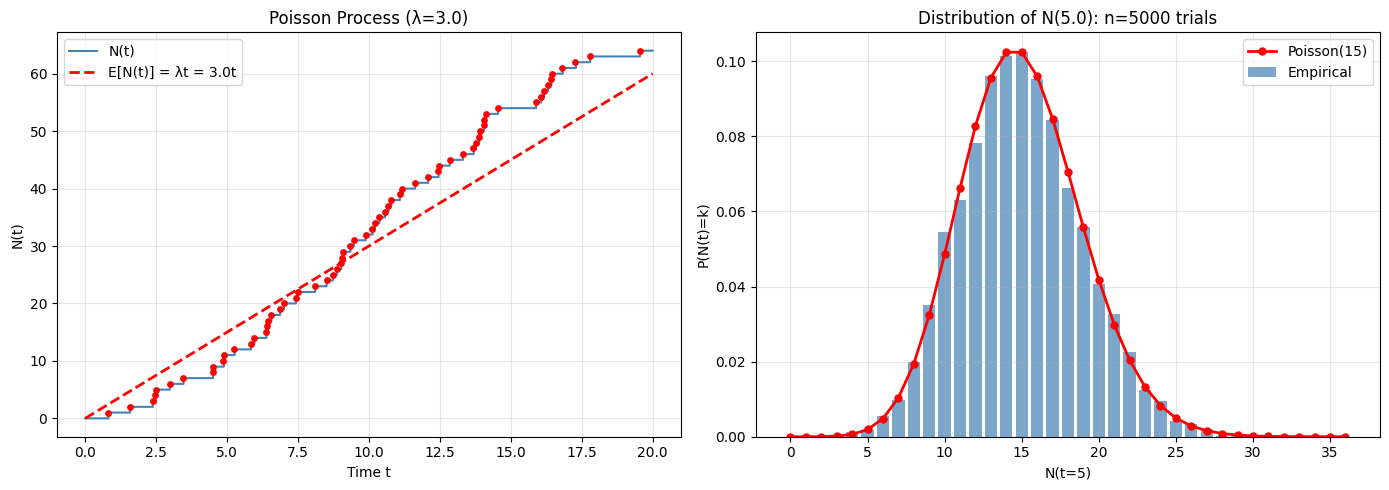

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

## 1. The Poisson Process
# Events arrive at rate lambda. Inter-arrival times ~ Exp(lambda).
# N(t) = number of arrivals by time t ~ Poisson(lambda * t)

def simulate_poisson_process(rate, t_max, rng):
    """Simulate a homogeneous Poisson process up to t_max.
    
    Args:
        rate: arrival rate lambda (events per unit time)
        t_max: simulation end time
        rng: numpy random generator
    
    Returns:
        arrival_times: array of arrival times in [0, t_max]
    """
    # Generate Exponential inter-arrivals until we exceed t_max
    arrivals = []
    t = 0.0
    while True:
        inter_arrival = rng.exponential(1.0 / rate)
        t += inter_arrival
        if t > t_max:
            break
        arrivals.append(t)
    return np.array(arrivals)

lam = 3.0  # 3 arrivals per unit time
t_max = 20.0

arrivals = simulate_poisson_process(lam, t_max, rng)
print(f"λ={lam}, T={t_max}: observed {len(arrivals)} arrivals")
print(f"Expected: {lam * t_max:.1f}, Std: {np.sqrt(lam * t_max):.2f}")

# Count process N(t)
t_grid = np.linspace(0, t_max, 1000)
N_t = np.array([np.sum(arrivals <= t) for t in t_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(t_grid, N_t, where='post', color='steelblue', linewidth=1.5, label='N(t)')
axes[0].plot(t_grid, lam * t_grid, 'r--', linewidth=2, label=f'E[N(t)] = λt = {lam}t')
axes[0].scatter(arrivals, np.arange(1, len(arrivals)+1), color='red', s=15, zorder=5)
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('N(t)')
axes[0].set_title(f'Poisson Process (λ={lam})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of N(t=5): should be Poisson(lambda*5)
t_check = 5.0
n_trials = 5000
counts = [len(simulate_poisson_process(lam, t_check, rng)) for _ in range(n_trials)]
expected_lam = lam * t_check

k_vals = np.arange(0, int(expected_lam * 2.5))
axes[1].bar(k_vals, [np.mean(np.array(counts) == k) for k in k_vals],
            alpha=0.7, color='steelblue', label='Empirical')
axes[1].plot(k_vals, stats.poisson.pmf(k_vals, expected_lam), 'ro-',
             linewidth=2, markersize=5, label=f'Poisson({expected_lam:.0f})')
axes[1].set_xlabel('N(t=5)')
axes[1].set_ylabel('P(N(t)=k)')
axes[1].set_title(f'Distribution of N({t_check}): n={n_trials} trials')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('poisson_process.png', dpi=120, bbox_inches='tight')
plt.show()

     λ      ρ    L (sim)   L (theory)    W (sim)   W (theory)
--------------------------------------------------------------
   1.0  0.200      0.251        0.250     0.2510       0.2500
   2.5  0.500      0.975        1.000     0.3902       0.4000
   3.5  0.700      2.506        2.333     0.7161       0.6667
   4.0  0.800      3.963        4.000     0.9908       1.0000
   4.5  0.900      7.301        9.000     1.6224       2.0000
   4.8  0.960     37.882       24.000     7.8922       5.0000


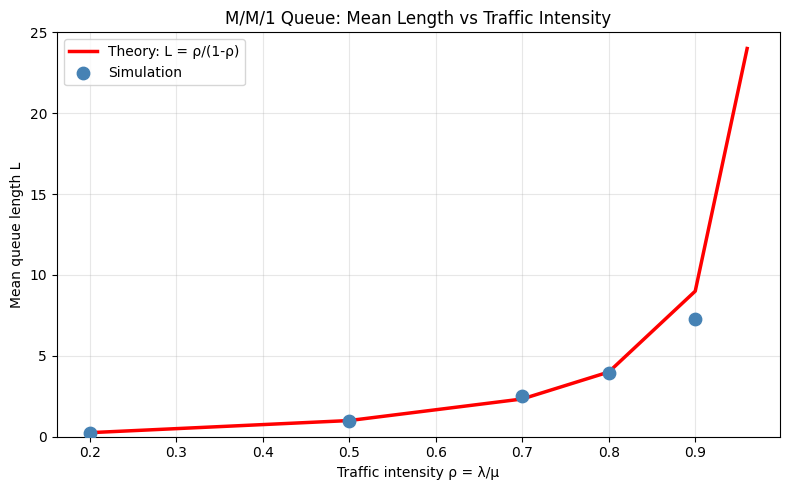

In [2]:
## 2. M/M/1 Queue
# Arrivals: Poisson(lambda). Service: Exp(mu). 1 server.
# Stability: rho = lambda/mu < 1.
# Exact results:
#   Mean queue length: L = rho / (1 - rho)
#   Mean waiting time: W = 1/(mu - lambda)  (Little's Law: L = lambda * W)

def simulate_mm1_queue(arrival_rate, service_rate, n_customers, rng):
    """Simulate M/M/1 queue and return waiting times.
    
    Args:
        arrival_rate: lambda (Poisson arrivals)
        service_rate: mu (Exponential service)
        n_customers: number of customers to simulate
        rng: numpy random generator
    
    Returns:
        waiting_times: time each customer waits in queue (before service)
        sojourn_times: total time in system (wait + service)
    """
    inter_arrivals = rng.exponential(1.0 / arrival_rate, n_customers)
    service_times = rng.exponential(1.0 / service_rate, n_customers)
    
    arrival_times = np.cumsum(inter_arrivals)
    waiting_times = np.zeros(n_customers)
    departure_times = np.zeros(n_customers)
    
    # Server is free at time 0
    server_free_at = 0.0
    
    for i in range(n_customers):
        service_start = max(arrival_times[i], server_free_at)
        waiting_times[i] = service_start - arrival_times[i]
        departure_times[i] = service_start + service_times[i]
        server_free_at = departure_times[i]
    
    sojourn_times = waiting_times + service_times
    return waiting_times, sojourn_times

mu = 5.0  # service rate
lambdas = [1.0, 2.5, 3.5, 4.0, 4.5, 4.8]
n_customers = 20_000

print(f"{'λ':>6} {'ρ':>6} {'L (sim)':>10} {'L (theory)':>12} {'W (sim)':>10} {'W (theory)':>12}")
print("-" * 62)

L_sim_list, L_theory_list, rho_list = [], [], []

for lam in lambdas:
    rho = lam / mu
    wait, sojourn = simulate_mm1_queue(lam, mu, n_customers, rng)
    
    # Little's Law: L = lambda * W
    W_sim = sojourn.mean()
    L_sim = lam * W_sim
    
    W_theory = 1 / (mu - lam)
    L_theory = rho / (1 - rho)
    
    L_sim_list.append(L_sim)
    L_theory_list.append(L_theory)
    rho_list.append(rho)
    
    print(f"{lam:>6.1f} {rho:>6.3f} {L_sim:>10.3f} {L_theory:>12.3f} {W_sim:>10.4f} {W_theory:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rho_list, L_theory_list, 'r-', linewidth=2.5, label='Theory: L = ρ/(1-ρ)')
ax.scatter(rho_list, L_sim_list, color='steelblue', s=80, zorder=5,
           label='Simulation')
ax.set_xlabel('Traffic intensity ρ = λ/μ')
ax.set_ylabel('Mean queue length L')
ax.set_title('M/M/1 Queue: Mean Length vs Traffic Intensity')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 25)
plt.tight_layout()
plt.savefig('mm1_queue.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Forward References

- **ch285 — Large Scale Data** *(Part IX)*: Queuing theory governs distributed system design — understanding $\rho \to 1$ blowup is essential for capacity planning in ML pipelines.
- **ch257 — Markov Chains**: The M/M/1 queue is itself a CTMC (continuous-time Markov chain) on the state space $\{0, 1, 2, \ldots\}$, with its stationary distribution giving the equilibrium queue length distribution.